In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv('/content/drive/MyDrive/OnSafe/modeling_final.csv')

In [4]:
# 제외할 키워드 목록
exclude_keywords = ['video', 'file_id', 'frame', 'timestamp']

# 키워드가 하나라도 포함되면 제외
drop_col = [col for col in df.columns if not any(keyword in col.lower() for keyword in exclude_keywords)]

# 컬럼 선택
df = df[drop_col]

df

,neck_angle,neck_angular_velocity,neck_angular_acceleration,shoulder_balance_angle,shoulder_balance_angular_velocity,shoulder_balance_angular_acceleration,shoulder_left_angle,shoulder_left_angular_velocity,shoulder_left_angular_acceleration,shoulder_right_angle,...,spine_angular_acceleration,ankle_left_angle,ankle_left_angular_velocity,ankle_left_angular_acceleration,ankle_right_angle,ankle_right_angular_velocity,ankle_right_angular_acceleration,center_distance,center_speed,Label
0,20.680788,-12.271715,184.552498,117.980466,2498.058166,7052.299677,25.160310,365.426342,4574.281863,43.718651,...,-2055.415069,121.146172,-1041.416422,-5435.284408,134.870221,-1445.213398,-8822.845456,1.942890e-16,1.165734e-14,0.0
1,25.160022,6.151750,-3977.881772,126.860540,235.076656,-74874.669237,32.936111,152.476062,-12993.440283,49.397831,...,-6805.643321,107.223897,-181.176147,40327.731608,116.830968,-294.094849,53051.507406,3.955170e-16,2.373102e-14,0.0
2,20.885847,-144.867774,-425.943202,125.816355,2.235858,-8595.416016,30.242845,-67.688334,-5016.894535,50.575347,...,3083.921846,115.106967,302.841298,7890.131248,125.067060,323.170182,12170.580699,4.437638e-16,2.662583e-14,0.0
3,20.331096,-8.046357,4197.226968,126.935069,-51.437211,1911.131293,30.679833,-14.753756,-542.685302,53.972380,...,10712.091864,117.318607,81.828228,-9271.617768,127.603307,111.591175,-7018.747461,2.087443e-16,1.252466e-14,0.0
4,20.617635,-4.960209,-323.045662,124.101781,65.940234,8833.618161,29.751053,-85.777844,-941.782118,48.057296,...,-438.093245,117.834575,-6.212628,-5679.841082,128.786766,89.211933,-2096.623552,2.498002e-16,1.498801e-14,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296562,25.626388,31.437188,-739.170751,116.499138,-91.135295,1752.576522,14.011173,-2.501825,-726.467353,50.954784,...,-73.892263,116.095380,-24.295745,454.977069,107.489540,-32.471702,-799.993634,4.996004e-16,1.448841e-14,1.0
296563,26.102950,-14.325184,-1129.321421,114.687117,27.905029,3241.283093,13.426289,-28.977733,-756.436352,51.931975,...,11.409774,115.623805,14.651826,1599.422870,106.294996,-32.522526,696.040891,2.498002e-16,7.244205e-15,1.0
296564,24.638445,-46.447048,53.555766,118.423623,132.401470,-598.446070,12.012709,-54.669849,1400.294337,51.446722,...,-529.589874,117.105850,86.009281,375.720456,105.246607,15.531118,633.252007,3.532708e-16,1.024485e-14,1.0
296565,22.899705,-10.631683,7443.498688,123.818253,-13.367114,-12608.788308,9.655955,67.594290,6448.057128,58.201012,...,-9117.846468,121.555480,40.563581,-2798.553521,107.366108,11.150026,-79.421324,3.532708e-16,1.024485e-14,1.0


In [5]:
X = df.drop(columns='Label')
y = df['Label']

In [6]:
# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 데이터프레임 구조 유지 (XGBoost 컬럼 매칭용)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

# 3. 데이터 불균형 해소 (SMOTE)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("원본 전체 데이터 분포:\n", y.value_counts())
print("SMOTE 적용 후 훈련 데이터 분포:\n", y_train_res.value_counts())

# 4. 지정한 최적 파라미터 기반 모델 정의
model = XGBClassifier(
    max_depth=5,
    n_estimators=298,
    learning_rate=0.27498459031412303,
    random_state=42,
    eval_metric='logloss'
)

# ★ 중요 수정: SMOTE와 스케일링이 완료된 최종 데이터로 모델 학습 진행
model.fit(X_train_res, y_train_res)

# 5. 예측 확률 계산 단계 (이후 ROC 커브용)
# ★ 중요 수정: 검증할 때도 원본 X_test가 아닌 스케일링된 X_test_scaled를 입력해야 함
y_probs = model.predict_proba(X_test_scaled)[:, 1]

원본 전체 데이터 분포:
 Label
1.0    194917
0.0    101650
Name: count, dtype: int64
SMOTE 적용 후 훈련 데이터 분포:
 Label
1.0    155933
0.0    155933
Name: count, dtype: int64


In [8]:
y_test_array = np.array(y_test) # ★ 판다스 인덱스 꼬임 방지 핵심 코드 (유지)

# 통계적으로 가장 효율적인 임계값 탐색 (이하 로직은 동일)
thresholds = np.linspace(0, 1, 100)
best_threshold = 0
max_efficiency = -1

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test_array, y_pred)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        efficiency = sensitivity + specificity

        if efficiency > max_efficiency:
            max_efficiency = efficiency
            best_threshold = t

print(f"\n▶ 통계적으로 가장 효율적인 임계값(Best Threshold): {best_threshold:.4f}")

# 최적 임계값을 적용하여 리포트 출력
final_pred = (y_probs >= best_threshold).astype(int)
print("\n" + "="*20 + " 최종 Classification Report " + "="*20)
print(classification_report(y_test_array, final_pred, target_names=['정상 (Normal)', '낙상 (Fall)']))
print("=" * 63)


▶ 통계적으로 가장 효율적인 임계값(Best Threshold): 0.5859

==================== 최종 Classification Report ====================
              precision    recall  f1-score   support

 정상 (Normal)       0.87      0.92      0.89     20330
   낙상 (Fall)       0.96      0.93      0.94     38984

    accuracy                           0.92     59314
   macro avg       0.91      0.92      0.92     59314
weighted avg       0.93      0.92      0.92     59314



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

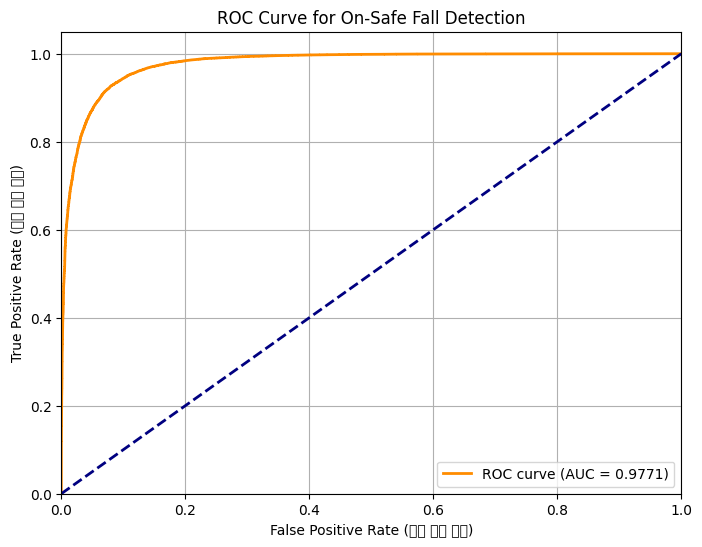

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 인덱스가 정렬된 데이터를 바탕으로 ROC 계산
fpr, tpr, _ = roc_curve(y_test_array, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# [수정 분기] matplotlib의 font_manager를 직접 참조하도록 수정
plt.rc('font', family='NanumBarunGothic' if 'NanumBarunGothic' in [f.name for f in mpl.font_manager.fontManager.ttflist] else 'sans-serif')
plt.rcParams['axes.unicode_minus'] = False

# 그래프 그리기
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (거짓 양성 비율)')
plt.ylabel('True Positive Rate (진짜 양성 비율)')
plt.title('ROC Curve for On-Safe Fall Detection')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [10]:
# y_probs = model.predict_proba(X_test)[:, 1]

# y_test_array = np.array(y_test)

# for t in thresholds:
#     # 정렬된 배열을 사용하여 예측 라벨 생성
#     y_pred = (y_probs >= t).astype(int)

#     # 혼동 행렬 계산
#     cm = confusion_matrix(y_test_array, y_pred)

#     # 클래스가 0, 1 모두 존재하는지 안전하게 체크 후 평가지표 계산
#     if cm.shape == (2, 2):
#         tn, fp, fn, tp = cm.ravel()

#         # 기존에 사용하던 효율성 산식을 적용 (예: 정확도 + 재현율 등)
#         # 여기서는 예시로 가장 많이 쓰이는 (Sensitivity + Specificity) 평가지표를 기준으로 잡음
#         sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
#         specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
#         efficiency = sensitivity + specificity

#         if efficiency > max_efficiency:
#             max_efficiency = efficiency
#             best_threshold = t

# print(f"통계적으로 가장 효율적인 임계값(Threshold): {best_threshold:.4f}")

In [11]:
# fpr, tpr, _ = roc_curve(y_test_array, y_probs)
# roc_auc = auc(fpr, tpr)

In [12]:
# from sklearn.metrics import classification_report

# final_pred = (y_probs >= best_threshold).astype(int)
# print("\n" + "="*20 + " Classification Report " + "="*20)
# print(classification_report(y_test_array, final_pred, target_names=['정상 (Normal)', '낙상 (Fall)']))
# print("="*63)

In [13]:
# plt.figure(figsize=(8, 6))

In [14]:
# # 시스템 환경에 맞는 한글 폰트 설정 (윈도우: Malgun Gothic / 맥: AppleGothic)
# plt.rc('font', family='Malgun Gothic')
# plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# # ROC 커브 그리기
# plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 무작위 예측 선

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate (거짓 양성 비율)')
# plt.ylabel('True Positive Rate (진짜 양성 비율)')
# plt.title('ROC Curve for On-Safe Fall Detection')
# plt.legend(loc="lower right")
# plt.grid(True)
# plt.show()